PART 2  Data Analysis & Preprocessing
---------------------------------------
---------------------------------------

In [3]:
import pandas as pd   #importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [4]:
Penguin_data = pd.read_csv('../data/preprocessed_penguins.csv') #cleaned dataset of penguind

# Select target Y (predicts penguin gender)
X = Penguin_data[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].values
Y = Penguin_data['gender'].apply(lambda x: 1 if x == 'male' else 0).values  # 1 for male, 0 for female

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [6]:
class LogistRegression:         #Building LogisticRegression
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    # Sigmoid function
    def sigmoid_f(self, z):
        return 1 / (1 + np.exp(-z))

    # Cost function
    def cost_f(self, y, y_hat):
        m = y.shape[0]
        return (-1 / m) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    # Gradient Descent for weights and bias
    def gradient_descentwb(self, X, y):
        m, n = X.shape
        self.weights = np.random.randn(n)  # Random weight initialization
        self.bias = 0

        for i in range(self.iterations):
            # Linear prediction
            z = np.dot(X, self.weights) + self.bias
            # Sigmoid to get probabilities
            y_hat = self.sigmoid_f(z)

            # Calculate gradients
            dw = (1 / m) * np.dot(X.T, (y_hat - y))
            db = (1 / m) * np.sum(y_hat - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Calculate and record loss
            loss = self.cost_f(y, y_hat)
            self.loss_history.append(loss)

    # Fit the model
    def fit(self, X, y):
        self.gradient_descentwb(X, y)

    # Predict binary labels
    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_hat = self.sigmoid_f(z)
        return np.where(y_hat >= 0.5, 1, 0)

In [7]:
learning_rates = [1e-3, 1e-2, 1e-4]   #defining the model parameters
iterations = [50000, 100000, 150000]
best_model = None
best_model_accuracy = 0
for lr in learning_rates:       #iterations
    for iter_count in iterations:
        print(f"\nTraining model with learning rate: {lr}, iterations: {iter_count}")
        model = LogistRegression(learning_rate=lr, iterations=iter_count)
        model.fit(X_train, y_train)

        # Make predictions on the test set
        y_pred = model.predict(X_test)

        # Calculates accuracy
        accuracy = np.mean(y_pred == y_test) * 100
        print(f"Accuracy: {accuracy}%")

        # Saves best model based on accuracy
        if accuracy > best_model_accuracy:
            best_model_accuracy = accuracy
            best_model = model

with open('meerahus_assignment1_part2.pkl', 'wb') as f:    #pickle file for storing the weights
    pickle.dump({'weights': best_model.weights, 'bias': best_model.bias}, f)
print(f"Best model saved with accuracy: {best_model_accuracy}%")



Training model with learning rate: 0.001, iterations: 50000
Accuracy: 79.71014492753623%

Training model with learning rate: 0.001, iterations: 100000
Accuracy: 91.30434782608695%

Training model with learning rate: 0.001, iterations: 150000
Accuracy: 92.7536231884058%

Training model with learning rate: 0.01, iterations: 50000
Accuracy: 88.40579710144928%

Training model with learning rate: 0.01, iterations: 100000
Accuracy: 88.40579710144928%

Training model with learning rate: 0.01, iterations: 150000
Accuracy: 88.40579710144928%

Training model with learning rate: 0.0001, iterations: 50000
Accuracy: 71.01449275362319%

Training model with learning rate: 0.0001, iterations: 100000
Accuracy: 56.52173913043478%

Training model with learning rate: 0.0001, iterations: 150000
Accuracy: 59.42028985507246%
Best model saved with accuracy: 92.7536231884058%


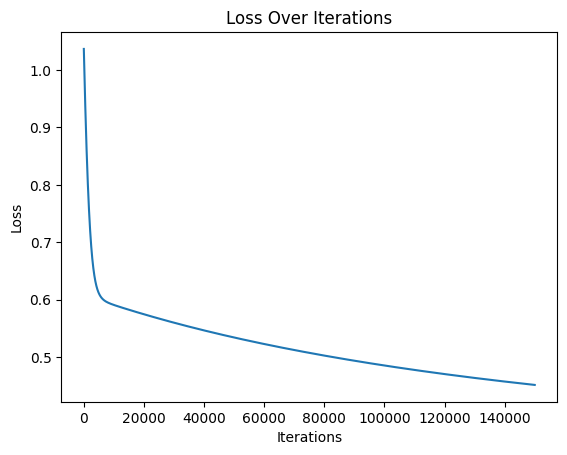

In [9]:
plt.plot(best_model.loss_history)
plt.title("Loss Over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [ ]:
'Refernces Used: https://www.w3schools.com/python/,https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html,https://www.geeksforgeeks.org/understanding-logistic-regression/ ,https://wiki.python.org/moin/UsingPickle'

'Refernces Used: https://www.w3schools.com/python/,https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html,https://www.geeksforgeeks.org/understanding-logistic-regression/ ,https://wiki.python.org/moin/UsingPickle'